In [88]:
!pip install pyphen -q

In [89]:
# https://judge.nitro-ai.org/competitions/nitro/nitro-nlp-hackathon-2026/1/view

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch 
from torch import nn 
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import pyphen
from torch.utils.data import Dataset, DataLoader
from IPython.display import clear_output
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from string import punctuation
import time

def eval_metric(y_true, preds):
    y_true = y_true.astype(float)
    preds = preds.astype(float)
    r2 = r2_score(y_true, preds, sample_weight=None, force_finite=True)
    r2 = max(0, r2)
    pears = pearsonr(y_true, preds)[0]
    if np.isnan(pears):
        pears = 0.0
    pears = np.abs(pears)
    return 100*(pears + r2)/2

In [90]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/nitro-nlp-hackathon-5th-edition/train_data.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/nitro-nlp-hackathon-5th-edition/test_data.csv")
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/nitro-nlp-hackathon-5th-edition/sample_output.csv")

train.shape, test.shape, subm.shape

((135210, 5), (9425, 5), (9425, 3))

In [91]:
chars = set(''.join(train['word'].tolist())).union(set(''.join(test['word'].tolist())))
chars.add('-')
chars = sorted(list(chars))
char2id = {c: i+1 for i, c in enumerate(chars)}
id2char = {i+1: c for i, c in enumerate(chars)}
len(chars), chars[:5]

(82, ['!', '%', '(', ')', '+'])

In [92]:
max(len(p) for p in train['word'].tolist()), max(len(p) for p in test['word'].tolist())

(47, 37)

In [93]:
vowels = ['a', 'e', 'i', 'o', 'u', 'ă', 'â', 'î']

ro_pyphen = pyphen.Pyphen(lang='ro_RO')

def count_syllables(word):
    word_hyphens = ro_pyphen.inserted(word)
    if '-' in word_hyphens:
        return len(word_hyphens.split('-'))
    return 1

def encode_word(word, max_len=47):
    word = ro_pyphen.inserted(word)
    ids = [char2id.get(c, 0) for c in word]
    ids = ids[:max_len]
    for i in range(max_len-len(ids)):
        ids.append(0)
    return ids

def get_embeddings(words, word_ids):
    embs = torch.zeros((len(words), 11))

    embs[:, 0] = torch.tensor([float(word_id.split('_')[-2]) for word_id in word_ids])
    embs[:, 1] = torch.tensor([float(word_id.split('_')[-1]) for word_id in word_ids])
    embs[:, 2] = torch.tensor([float(word[-1] in punctuation) for word in words])
    embs[:, 3] = torch.tensor([float(len(word)) for word in words])
    embs[:, 4] = torch.tensor([float(word[0].isupper()) for word in words])
    embs[:, 5] = torch.tensor([float(count_syllables(word)) for word in words])
    embs[:, 6] = torch.tensor([float(word[-1].lower() in vowels) if word[-1] not in punctuation or len(word)<2 else float(word[-2].lower() in vowels) for word in words])
    embs[:, 7] = torch.tensor([float(word[0].lower() in vowels) for word in words])
    embs[:, 8] = torch.tensor([float(word.startswith('https') or word.startswith('www')) for word in words])
    embs[:, 9] = torch.tensor([float(sum(1 if '0'<=ch<='9' else 0 for ch in word)) for word in words])
    embs[:, 10] = torch.tensor([float(sum(float(ch in punctuation) for ch in word)) for word in words])

    return embs


In [94]:
valid_text = 'popsci_caveman'

valid = train[train['text'] == valid_text]
train = train[train['text'] != valid_text]

train, valid = train.reset_index(drop=True), valid.reset_index(drop=True)

train.shape, valid.shape

((122550, 5), (12660, 5))

In [95]:
train_embeddingss = []

for group in train.groupby(['text', 'participant_id']):
    fragment = group[1]
    embs = get_embeddings(fragment['word'], fragment['word_id'])
    train_embeddingss.append(embs)

train_embeddingss = torch.cat(train_embeddingss)
mean = train_embeddingss.mean(axis=0)
std = train_embeddingss.std(axis=0) + 1e-6

mean, std

(tensor([5.8406e+00, 3.5611e+01, 1.1603e-01, 5.3349e+00, 7.8580e-02, 2.1540e+00,
         6.2056e-01, 2.4308e-01, 7.3439e-04, 1.2485e-02, 1.4786e-01]),
 tensor([ 3.5911, 24.4428,  0.3203,  3.2283,  0.2691,  1.3025,  0.4852,  0.4289,
          0.0271,  0.2258,  0.3973]))

In [96]:
class WordDataset(Dataset):
    def __init__(self, df, mean=None, std=None):
        self.df = df 
        self.embeddingss = []
        self.wordss = []
        self.answerss = []
        self.mean = mean
        self.std = std

        for group in df.groupby(['text', 'participant_id']):
            fragment = group[1]
            embs = get_embeddings(fragment['word'], fragment['word_id'])
            if 'answer' in fragment.columns:
                answers = torch.FloatTensor(fragment['answer'].tolist())
                # mean = answers.mean()
                # std = answers.std() + 1e-6
                # answers = (answers - mean) / std
            else:
                answers = None

            self.wordss.append(torch.stack([torch.LongTensor(encode_word(word)) for word in fragment['word'].tolist()]))
            self.embeddingss.append(embs)
            self.answerss.append(answers)

    def __len__(self):
        return len(self.embeddingss)

    def __getitem__(self, idx):
        embs = self.embeddingss[idx]
        words = self.wordss[idx]
        if self.mean is not None and self.std is not None:
            embs = (embs - self.mean) / self.std
        if self.answerss[idx] is None:
            return embs, words
        answers = self.answerss[idx]
        return embs, words, answers

train_ds = WordDataset(train, mean, std)
valid_ds = WordDataset(valid, mean, std)
test_ds = WordDataset(test, mean, std)

BATCH_SIZE = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

(240, 30, 15)

In [97]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [98]:
class WordModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=11, num_layers=1, rnn_type='GRU', bidirectional=False, dropout=0.0, char_emb_size=32, device=device):
        super().__init__()
        self.device = device
        self.char_embs = nn.Embedding(len(chars)+1, char_emb_size)
        
        if rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size+char_emb_size, hidden_size, num_layers=num_layers, bidirectional=bidirectional, batch_first=True, dropout=dropout)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size+char_emb_size, hidden_size, num_layers=num_layers, bidirectional=bidirectional, batch_first=True, dropout=dropout)
        else:
            raise ValueError('Эээ братуха какой рнн скажи нормально')

        self.char_rnn = nn.LSTM(char_emb_size, char_emb_size, batch_first=True)
        
        self.head = nn.Sequential(
            nn.Linear(hidden_size*(2 if bidirectional else 1), hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def get_word_repr(self, words):
        embs = self.char_embs(words)
        _, (h, _) = self.char_rnn(embs)
        return h[-1].unsqueeze(0)
        
    def forward(self, embs, words):
        word_repr = self.get_word_repr(words[0])
        embs = torch.cat([embs, word_repr], dim=-1)
        output, _ = self.rnn(embs)
        return self.head(output.squeeze(0)).squeeze()

In [99]:
def fit_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    i, rloss, all_preds, all_targets = 0, 0, [], []
    for X, words, y in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        X, y = X.to(device), y.to(device).squeeze(0)
        words = words.to(device)
        preds = model(X, words)
        loss = criterion(preds, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        i += 1
        rloss += loss.item()
        all_targets.extend(y.detach().cpu().tolist())
        all_preds.extend(preds.detach().cpu().tolist())
        cur_loss = rloss / i 
        cur_metric = eval_metric(np.array(all_targets), np.array(all_preds))
        pbar.set_postfix({'loss': f'{cur_loss:.6f}', 'metric': f'{cur_metric:.6f}'})

    return cur_loss, cur_metric

@torch.no_grad()
def eval_one_epoch(model, criterion, valid_loader, device):
    model.eval()
    i, rloss, all_preds, all_targets = 0, 0, [], []
    for X, words, y in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        X, y = X.to(device), y.to(device).squeeze(0)
        words = words.to(device)
        preds = model(X, words)
        loss = criterion(preds, y)

        i += 1
        rloss += loss.item()
        all_targets.extend(y.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        cur_loss = rloss / i 
        cur_metric = eval_metric(np.array(all_targets), np.array(all_preds))
        pbar.set_postfix({'loss': f'{cur_loss:.6f}', 'metric': f'{cur_metric:.6f}'})
        
    return cur_loss, cur_metric

def plot_history(history, plot_title):
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.suptitle(plot_title)

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Losses')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_metric'], label='train')
    plt.plot(history['valid_metric'], label='valid')
    plt.xlabel('epoch')
    plt.ylabel('metric')
    plt.title('Metrics')
    plt.legend()

    plt.show()

def fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, device, epochs, history=None, plot_extra_text=''):
    if history is None:
        history = {
            'train_loss': [],
            'valid_loss': [],
            'train_metric': [],
            'valid_metric': []
        }

    for epoch in range(epochs):
        tloss, tmet = fit_one_epoch(model, optimizer, criterion, train_loader, device)
        vloss, vmet = eval_one_epoch(model, criterion, valid_loader, device)

        history['train_loss'].append(tloss)
        history['valid_loss'].append(vloss)
        history['train_metric'].append(tmet)
        history['valid_metric'].append(vmet)

        plot_title = f'Epoch: {epoch+1}/{epochs} | LR: {scheduler.get_last_lr()[0]:.6f}' + plot_extra_text
        plot_history(history, plot_title)

        scheduler.step()

In [100]:
def corr_loss(output, y):
    vx = output - output.mean()
    vy = y - y.mean()
    corr = (vx * vy).mean() / (vx.std() + vy.std() + 1e-6)
    return 1 - corr

def custom_loss(output, y, beta=0.5):
    mse = F.mse_loss(output, y)
    corr = corr_loss(output, y)
    return mse + beta * corr

In [101]:
start_time = time.time()
start_time

1777187696.436077

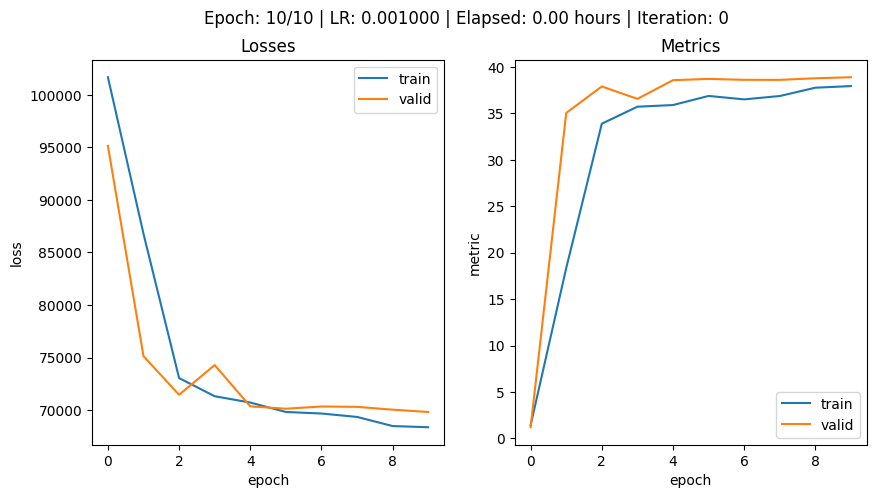

In [102]:
iteration, max_iterations = 0, 1
max_time_hours = 5.95
history = None

while iteration < max_iterations and (time.time() - start_time) / 3600 < max_time_hours:
    epochs = 10
    model = WordModel(hidden_size=256, num_layers=1, rnn_type='LSTM', bidirectional=True, dropout=0.2, char_emb_size=4).to(device)
    if iteration != 0:
        model.load_state_dict(torch.load(f'model_weights{iteration-1}.pth'))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ConstantLR(optimizer, 1.0)
    criterion = nn.MSELoss()

    plot_extra_text = f' | Elapsed: {((time.time() - start_time) / 3600):.2f} hours | Iteration: {iteration}'
    
    history = fit(model, optimizer, scheduler, criterion, train_loader, valid_loader, device, epochs, history, plot_extra_text)
    
    torch.save(model.state_dict(), f'model_weights{iteration}.pth')
    iteration += 1

In [105]:
model = WordModel(hidden_size=256, num_layers=1, rnn_type='LSTM', bidirectional=True, dropout=0.2, char_emb_size=4).to(device)
model.load_state_dict(torch.load(f'model_weights{iteration-1}.pth'))

@torch.no_grad()
def inference(model, test_loader):
    model.eval()
    all_preds = []
    for X, words in (pbar := tqdm(test_loader, desc='Test Loader', leave=False)):
        X = X.to(device)
        words = words.to(device)
        preds = model(X, words)
        all_preds.append(preds.cpu().tolist())

    return all_preds 

preds = inference(model, test_loader)

Test Loader:   0%|          | 0/15 [00:00<?, ?it/s]

In [116]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/nitro-nlp-hackathon-5th-edition/train_data.csv")

zeros_perc = []

for group in train.groupby(['text', 'participant_id']):
    fragment = group[1]
    zeros_perc.append((fragment['answer']==0).mean())

zeros_perc = np.mean(zeros_perc).item()
zeros_perc

0.3040845131120179

In [120]:
dpids = []
arranged_preds = []

for i, group in enumerate(test.groupby(['text', 'participant_id'])):
    dpids.extend(group[1]['datapointID'].tolist())
    thresh = np.quantile(preds[i], zeros_perc)
    preds[i] = [p if p >= thresh else 0 for p in preds[i]]
    arranged_preds.extend(preds[i])

subm = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': dpids,
    'answer': arranged_preds
})

subm.to_csv("submission.csv", index=False)

subm.head()

,subtaskID,datapointID,answer
0,1,4430,346.402618
1,1,4431,0.000000
2,1,4432,300.519775
3,1,4433,0.000000
4,1,4434,571.185913
